# Predição de ativos da bolsa de valores

## Import Libraries

In [161]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils


In [162]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras

In [163]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from ProcessingPipeline import FeaturesDataGenerator, scrapingHistoricalData

## Init parameters

In [164]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', ]
                    #'Volume_log','Chaikin_Money_Flow', 'Williams_R,'PPO',]


# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',
                    
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
 
                    'RSI_14' ,
                    'MACD', 'MACD_Signal', 'MACD_Histogram',
 
                    'Stochastic_K', 'Stochastic_D',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC']  

features_indicators=[ 'Close', 'Open', 'High', 'Low', 'Volume',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']


In [165]:


pred_days = int(24/4 * 2) 
buy_sell_threshold=[0.05,-0.05]
lookback = int(4 * 4) 
batch_size = 16
shuffle = True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [166]:
input_shape

(16, 24)

## Deep Learning Model

In [167]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="Attention_")
class Attention_(tf.keras.layers.Layer):
    def __init__(self, units,  **kwargs):
        super(Attention_, self).__init__( **kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def build(self, input_shape):
        self.W.build(input_shape)
        self.V.build(input_shape)

    def call(self, inputs):
        # Compute attention scores
        score = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=-1)

        # Apply attention weights to input
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=-1)

        return context_vector

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [168]:
# Model name
model_name = "CNN_MultiHead"
#np.random.seed(42)

# Importe as bibliotecas necessárias
from keras.layers import Dropout
from keras.regularizers import l2

# Defina a taxa de dropout
dropout_rate = 0.2

# Defina a magnitude da L2 regularization
l2_regularization = 0.01

# Aplique o dropout às camadas do modelo
def common_layers(input1):
    # ...
    conv_layer = Conv1D(64, (3), padding="same")(input1)
    conv_layer = BatchNormalization()(conv_layer)
    conv_layer = Activation('relu')(conv_layer)
    conv_layer = MaxPooling1D(pool_size=(3), strides=1, padding="same")(conv_layer)
    conv_layer = Dropout(dropout_rate)(conv_layer)  

    conv_layer = Conv1D(128, (3), padding="same")(input1)
    conv_layer = BatchNormalization()(conv_layer)
    conv_layer = Activation('relu')(conv_layer)
    conv_layer = MaxPooling1D(pool_size=(3), strides=2, padding="same")(conv_layer)
    conv_layer = Dropout(dropout_rate)(conv_layer)  # Adicione o dropout aqui
    # ...
    return conv_layer

def head_layer(conv_layer, num_classes, activation='linear', output_name=None):
    # ...
    head = Conv1D(264, (3), padding="same")(conv_layer)
    head = BatchNormalization()(head)
    head = Activation('relu')(head)
    head = MaxPooling1D(pool_size=(3), strides=2, padding="same")(head)
    head = Dropout(dropout_rate)(head)  # Adicione o dropout aqui
    # ...
    #head=Attention_(units=64)(head)
    head=Attention_(units=264)(head)
    #head = Flatten()(input_data)
    # Adicione a L2 regularization às camadas densas
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(head)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)  # Adicione o dropout aqui

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)  # Adicione o dropout aqui

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x

# Create the full model
input_data = Input(shape=input_shape)

Features = common_layers(input_data)
# Create separate heads with appropriate number of outputs and activations
#regression_output = head_layer(Features, num_classes=pred_days, activation='linear',output_name='regression_head')
classification_output = head_layer(Features, num_classes=n_classes, activation='softmax',output_name='classification_head')

# Create the model with two heads
model_CNN_MultiHead = Model(inputs=input_data, outputs=[classification_output])
model_CNN_MultiHead._name = model_name

# Print model summary
model_CNN_MultiHead.summary()

Model: "CNN_MultiHead"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 16, 24)]          0         
                                                                 
 conv1d_28 (Conv1D)          (None, 16, 128)           9344      
                                                                 
 batch_normalization_46 (Ba  (None, 16, 128)           512       
 tchNormalization)                                               
                                                                 
 activation_46 (Activation)  (None, 16, 128)           0         
                                                                 
 max_pooling1d_28 (MaxPooli  (None, 8, 128)            0         
 ng1D)                                                           
                                                                 
 dropout_46 (Dropout)        (None, 8, 128)          

In [169]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [170]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    return optimizer1
    #

#Train options callbacks

    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name):
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback


In [171]:
f'models/model_{model_name}_crypto_lookback_{lookback}'

'models/model_CNN_MultiHead_crypto_lookback_16'

In [172]:
list_of_models=[model_CNN_MultiHead]

## Load Data And train

In [173]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'

#df=SHD.get_crypto_historical_data(cryptos, interval, '2015-01-01')


In [174]:
import datetime
init_date = '2015-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 7


#cryptos_list = [ 'BTC','ETH','SOL','DOT','FET']
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


BTC Dataset Period:2015-01-01 : 2022-01-01
self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)
Train data shape (6626,)
Vall data shape (1104,)
Test data shape (1106,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:88: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:96: RuntimeWarning:

invalid value encountered in divide



self.pred_days 12


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:790: RuntimeWarning:

divide by zero encountered in log



input data shape (6610, 16, 24)
output data shape (6610, 3)
self.pred_days 12
input data shape (1088, 16, 24)
output data shape (1088, 3)
self.pred_days 12
input data shape (1090, 16, 24)
output data shape (1090, 3)
[0 1 2] [5884  366  360]
[ 0.37446182  6.02003643 12.24074074]
Training model : models/model_CNN_MultiHead_crypto_lookback_16
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss improved from inf to 3.35257, saving model to models\model_CNN_MultiHead_crypto_lookback_16
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_16\assets


...

413/413 - 13s - loss: 2.5896 - accuracy: 0.2833 - matthews_correlation_coefficient: -6.6199e-02 - val_loss: 3.1380 - val_accuracy: 0.2574 - val_matthews_correlation_coefficient: -2.4484e-01 - lr: 1.0000e-04 - 13s/epoch - 31ms/step
Epoch 3/200

Epoch 3: val_loss improved from 3.13796 to 2.86128, saving model to models\model_CNN_MultiHead_crypto_lookback_16
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_16\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_16\assets


413/413 - 13s - loss: 2.3086 - accuracy: 0.3691 - matthews_correlation_coefficient: 0.0526 - val_loss: 2.8613 - val_accuracy: 0.5983 - val_matthews_correlation_coefficient: 0.4194 - lr: 1.0000e-04 - 13s/epoch - 31ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 2.86128
413/413 - 7s - loss: 2.0952 - accuracy: 0.4681 - matthews_correlation_coefficient: 0.1882 - val_loss: 3.0226 - val_accuracy: 0.5947 - val_matthews_correlation_coefficient: 0.3892 - lr: 1.0000e-04 - 7s/epoch - 16ms/step
Epoch 5/200

Epoch 5: val_loss did not improve from 2.86128
413/413 - 7s - loss: 1.9149 - accuracy: 0.5340 - matthews_correlation_coefficient: 0.2865 - val_loss: 3.0785 - val_accuracy: 0.6489 - val_matthews_correlation_coefficient: 0.4491 - lr: 1.0000e-04 - 7s/epoch - 16ms/step
Epoch 6/200

Epoch 6: val_loss did not improve from 2.86128
413/413 - 7s - loss: 1.7342 - accuracy: 0.6200 - matthews_correlation_coefficient: 0.4218 - val_loss: 2.9514 - val_accuracy: 0.6875 - val_matthews_correlation_co

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_16\assets


413/413 - 12s - loss: 1.4826 - accuracy: 0.7529 - matthews_correlation_coefficient: 0.6271 - val_loss: 2.7386 - val_accuracy: 0.7978 - val_matthews_correlation_coefficient: 0.6967 - lr: 1.0000e-06 - 12s/epoch - 30ms/step
Epoch 11/200

Epoch 11: val_loss did not improve from 2.73860
413/413 - 7s - loss: 1.4712 - accuracy: 0.7365 - matthews_correlation_coefficient: 0.6007 - val_loss: 4.0362 - val_accuracy: 0.7785 - val_matthews_correlation_coefficient: 0.6677 - lr: 1.0000e-06 - 7s/epoch - 16ms/step
Epoch 12/200

Epoch 12: val_loss did not improve from 2.73860
413/413 - 7s - loss: 1.4256 - accuracy: 0.7621 - matthews_correlation_coefficient: 0.6393 - val_loss: 3.2400 - val_accuracy: 0.7463 - val_matthews_correlation_coefficient: 0.6293 - lr: 1.0000e-06 - 7s/epoch - 16ms/step
Epoch 13/200

Epoch 13: val_loss did not improve from 2.73860
413/413 - 7s - loss: 1.4440 - accuracy: 0.7449 - matthews_correlation_coefficient: 0.6138 - val_loss: 3.0312 - val_accuracy: 0.7500 - val_matthews_correlat

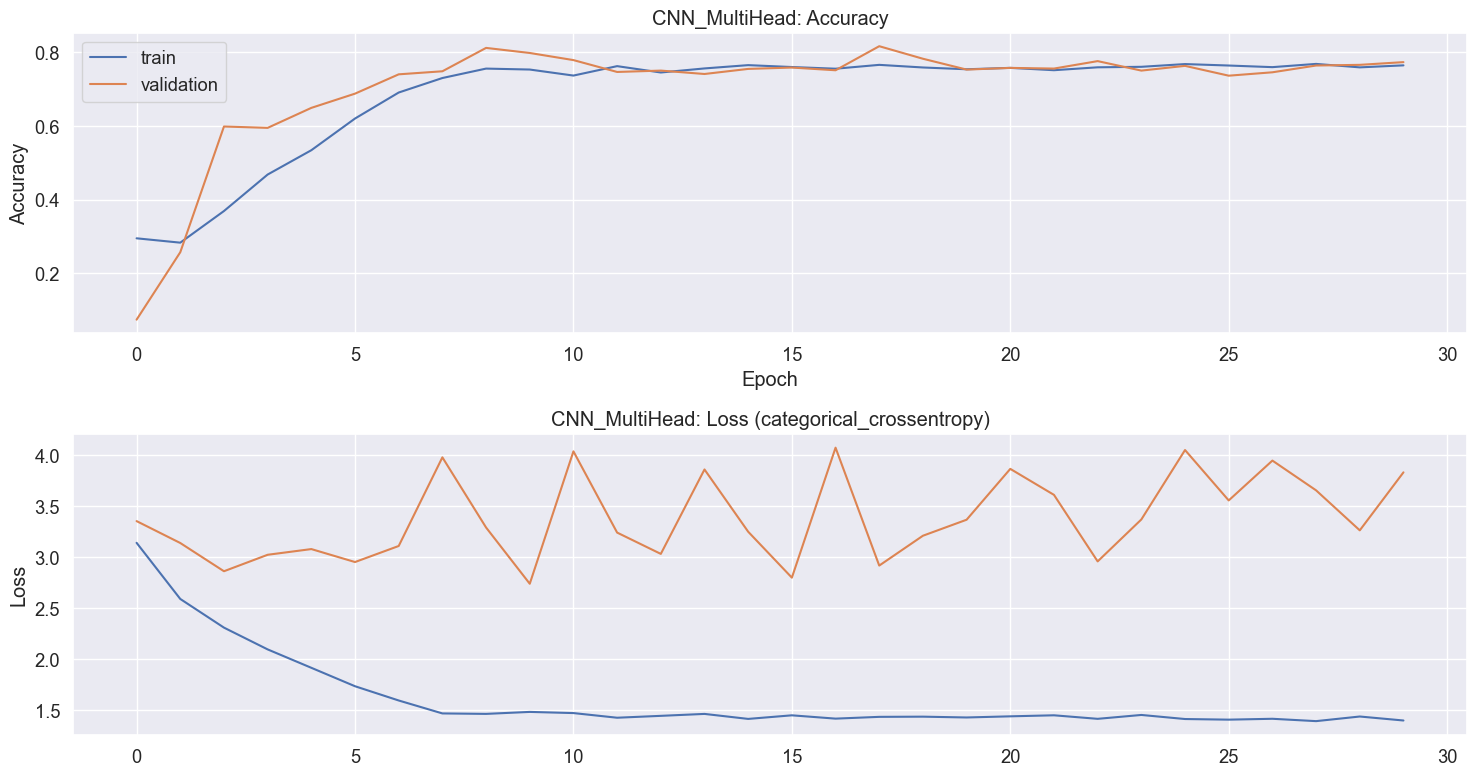

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



35/35 [==============================] - 1s 7ms/step
CNN_MultiHead  classification Accuracy 0.736697247706422
BTC Dataset Period:2016-01-01 : 2023-01-01
self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)
Train data shape (8121,)
Vall data shape (1354,)
Test data shape (1355,)
self.pred_days 12


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:88: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:96: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:790: RuntimeWarning:

divide by zero encountered in log



input data shape (8105, 16, 24)
output data shape (8105, 3)
self.pred_days 12
input data shape (1338, 16, 24)
output data shape (1338, 3)
self.pred_days 12
input data shape (1339, 16, 24)
output data shape (1339, 3)
[0 1 2] [7202  460  443]
[ 0.37512728  5.87318841 12.19714071]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200


...


Epoch 1: val_loss did not improve from 2.73860
506/506 - 14s - loss: 1.6761 - accuracy: 0.7306 - matthews_correlation_coefficient: 0.5905 - val_loss: 4.6398 - val_accuracy: 0.7922 - val_matthews_correlation_coefficient: 0.6883 - lr: 1.0000e-06 - 14s/epoch - 29ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 2.73860
506/506 - 8s - loss: 1.6347 - accuracy: 0.7267 - matthews_correlation_coefficient: 0.5871 - val_loss: 4.7431 - val_accuracy: 0.8080 - val_matthews_correlation_coefficient: 0.7169 - lr: 1.0000e-06 - 8s/epoch - 16ms/step
Epoch 3/200

Epoch 3: val_loss did not improve from 2.73860
506/506 - 8s - loss: 1.5975 - accuracy: 0.7311 - matthews_correlation_coefficient: 0.5934 - val_loss: 4.5142 - val_accuracy: 0.8050 - val_matthews_correlation_coefficient: 0.6973 - lr: 1.0000e-06 - 8s/epoch - 16ms/step
Epoch 4/200

Epoch 4: val_loss did not improve from 2.73860
506/506 - 8s - loss: 1.6288 - accuracy: 0.7304 - matthews_correlation_coefficient: 0.5921 - val_loss: 4.6647 - va

INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_crypto_lookback_16\assets


506/506 - 11s - loss: 1.4986 - accuracy: 0.7306 - matthews_correlation_coefficient: 0.5937 - val_loss: 2.5295 - val_accuracy: 0.8358 - val_matthews_correlation_coefficient: 0.7342 - lr: 1.0000e-12 - 11s/epoch - 22ms/step
Epoch 36/200


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide




Epoch 36: val_loss did not improve from 2.52946
506/506 - 7s - loss: 1.4879 - accuracy: 0.7370 - matthews_correlation_coefficient: 0.6012 - val_loss: 3.0612 - val_accuracy: 0.8471 - val_matthews_correlation_coefficient: 0.7494 - lr: 1.0000e-12 - 7s/epoch - 14ms/step
Epoch 37/200

Epoch 37: val_loss did not improve from 2.52946
506/506 - 7s - loss: 1.4948 - accuracy: 0.7316 - matthews_correlation_coefficient: 0.5961 - val_loss: 4.0129 - val_accuracy: 0.8087 - val_matthews_correlation_coefficient: 0.7309 - lr: 1.0000e-12 - 7s/epoch - 14ms/step
Epoch 38/200

Epoch 38: val_loss did not improve from 2.52946
506/506 - 7s - loss: 1.5292 - accuracy: 0.7249 - matthews_correlation_coefficient: 0.5855 - val_loss: 4.5097 - val_accuracy: 0.8020 - val_matthews_correlation_coefficient: 0.7054 - lr: 1.0000e-12 - 7s/epoch - 14ms/step
Epoch 39/200

Epoch 39: val_loss did not improve from 2.52946
506/506 - 7s - loss: 1.5097 - accuracy: 0.7268 - matthews_correlation_coefficient: 0.5871 - val_loss: 4.4962

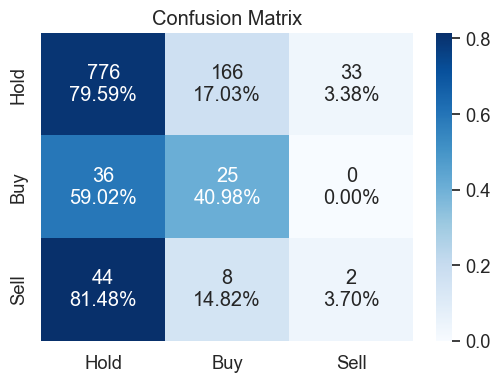

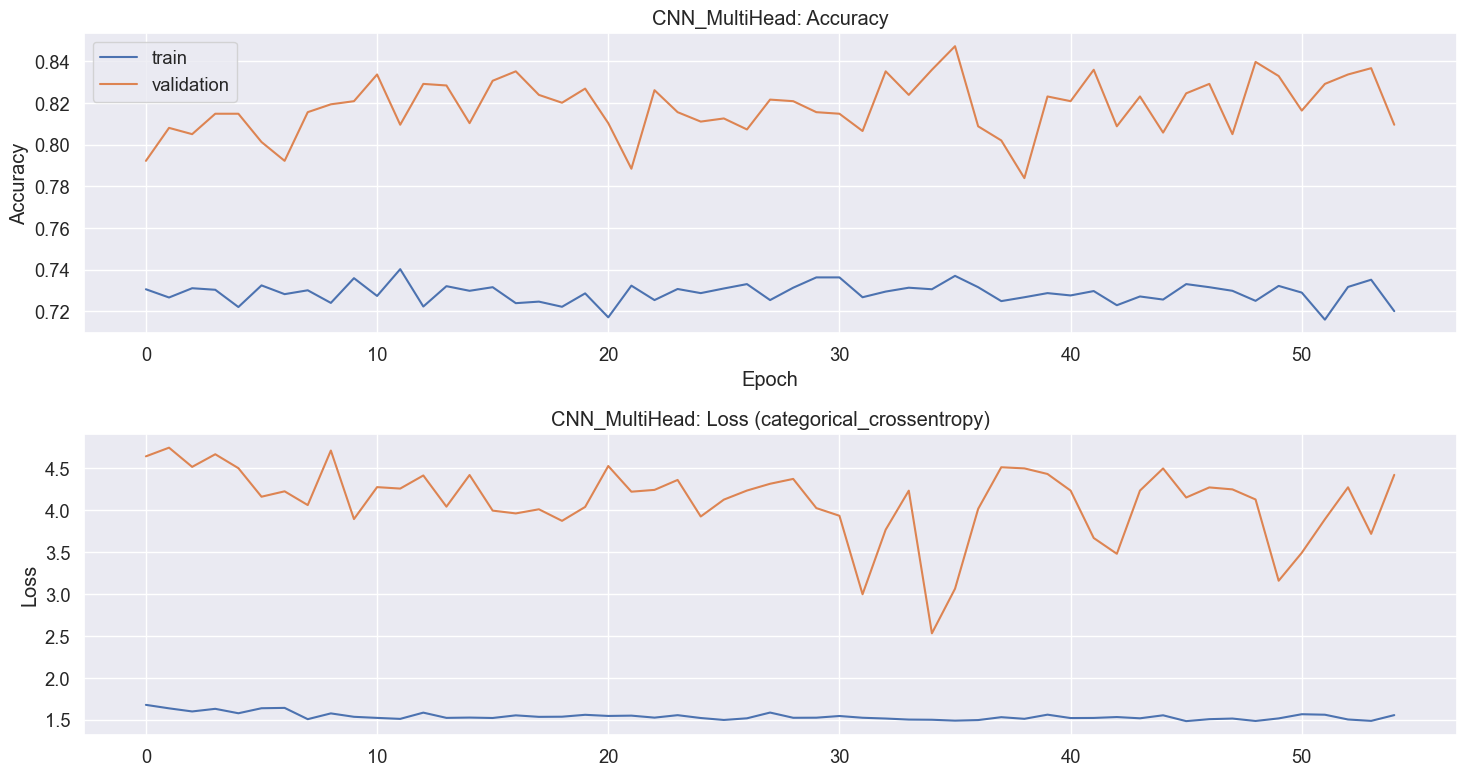

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



42/42 [==============================] - 1s 9ms/step
CNN_MultiHead  classification Accuracy 0.7408513816280807
BTC Dataset Period:2017-01-01 : 2024-12-21
self.pred_days 1
input data shape (19, 1, 28)
output data shape (19, 3)
Train data shape (11121,)
Vall data shape (1854,)
Test data shape (1855,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:88: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:96: RuntimeWarning:

invalid value encountered in divide



self.pred_days 12


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:790: RuntimeWarning:

divide by zero encountered in log



input data shape (11105, 16, 24)
output data shape (11105, 3)
self.pred_days 12
input data shape (1838, 16, 24)
output data shape (1838, 3)
self.pred_days 12
input data shape (1839, 16, 24)
output data shape (1839, 3)
[0 1 2] [9886  627  592]
[ 0.37443523  5.90377459 12.50563063]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train fo model: CNN_MultiHead
Epoch 1/200

Epoch 1: val_loss did not improve from 2.52946
694/694 - 14s - loss: 1.8178 - accuracy: 0.7004 - matthews_correlation_coefficient: 0.5472 - val_loss: 3.5277 - val_accuracy: 0.6990 - val_matthews_correlation_coefficient: 0.5485 - lr: 1.0000e-12 - 14s/epoch - 21ms/step
Epoch 2/200

Epoch 2: val_loss did not improve from 2.52946
694/694 - 9s - loss: 1.7841 - accuracy: 0.6965 - matthews_correlation_coefficient: 0.5409 - val_loss: 3.4260 - val_accuracy: 0.7237 - val_matthews_correlation_coefficient:

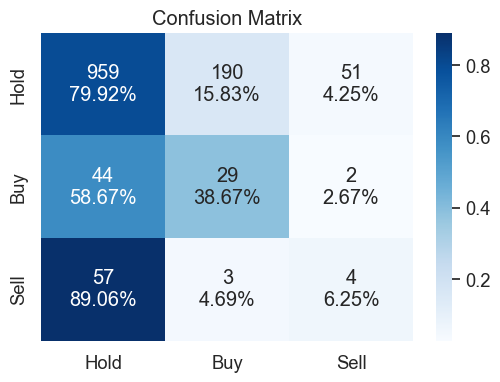

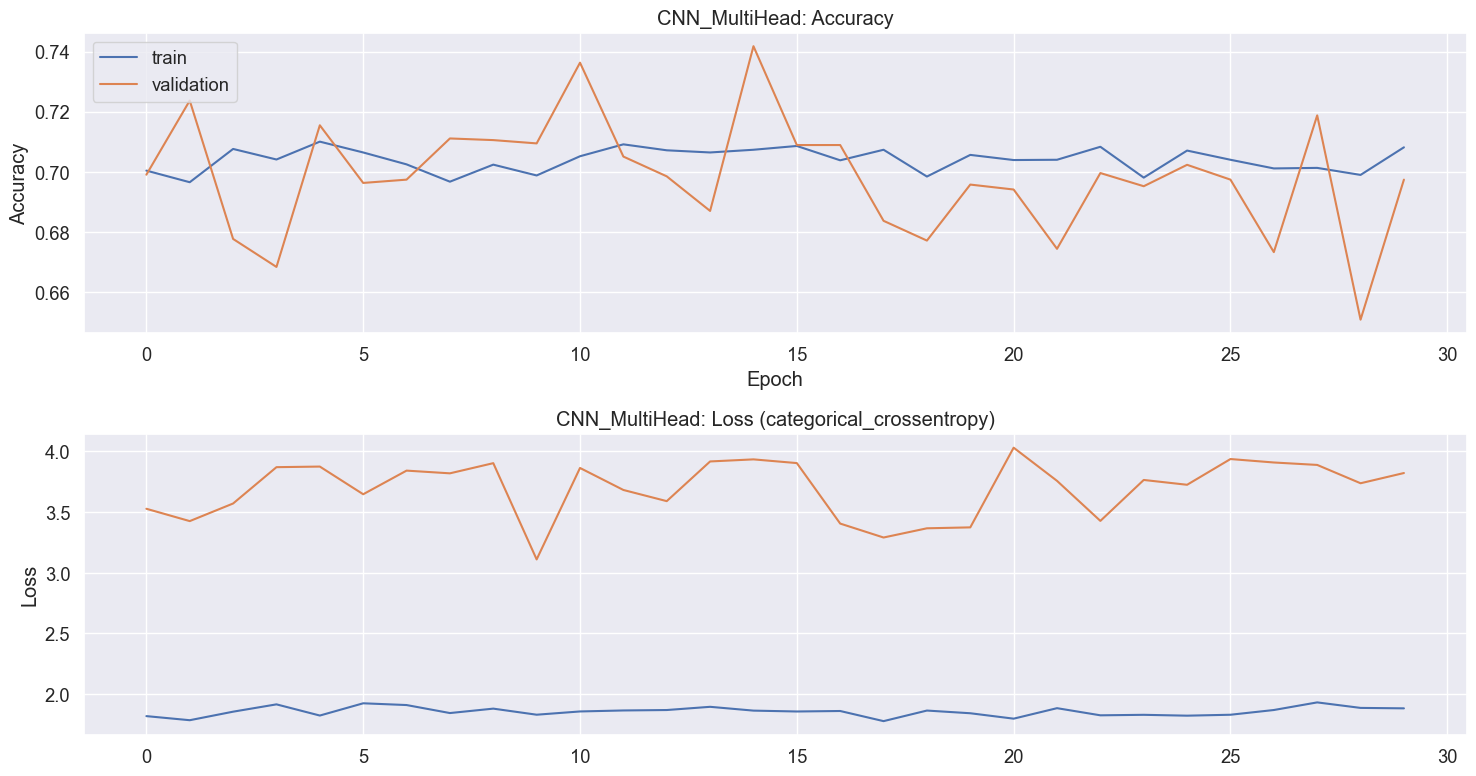

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead
Model name: CNN_MultiHead


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



58/58 [==============================] - 1s 8ms/step
CNN_MultiHead  classification Accuracy 0.7128874388254486


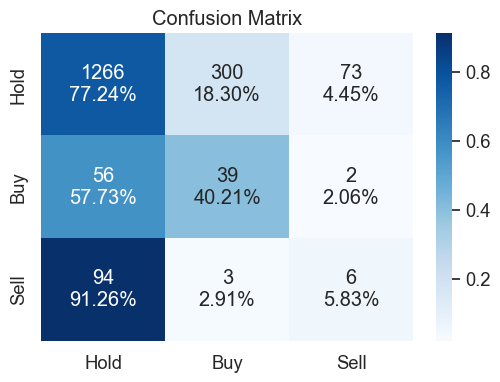

In [175]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 


        # Obtenha os dados históricos
        cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)
        
        # split the data in train validation and test

        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.75)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        # get train vall and test dataloader
        X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
        X_data_gen_val = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_val)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
        X_data_gen_test = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_test)].iloc[:,:], lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)
        output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

        # Ajusta o peso da primeira classe
        adjustment_factor = 2
        output_class_weights[2] = output_class_weights[2] * adjustment_factor

        # Normaliza os pesos novamente
        #output_class_weights = output_class_weights / np.sum(output_class_weights)
        print(output_class_weights)
        #output_class_weights = np.ones(3) 
        weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

        loss = weighted_categorical_crossentropy_loss

        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name)
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])
                idx=1
            else:
                model = trained_best_models[model._name]

            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train fo model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                verbose=2
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['accuracy'])
            axes[0].plot(history.history['val_accuracy'])
            axes[0].set_title(f'{model._name}: Accuracy')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()
        trained_best_models={}
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, compile=True)

            print('Model name:',model_name)

            x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)

            label_pred = trained_best_models[model_name].predict(x_data)
            print(model_name,' classification Accuracy',
                            utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                            np.argmax(label_pred,axis=1),average="micro"))

            cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            
            try:
                utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            except:
                print(cf_matrix)


Model name: CNN_MultiHead


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:348: RuntimeWarning:

invalid value encountered in divide



58/58 [==============================] - 0s 7ms/step
CNN_MultiHead  classification Accuracy 0.7128874388254486


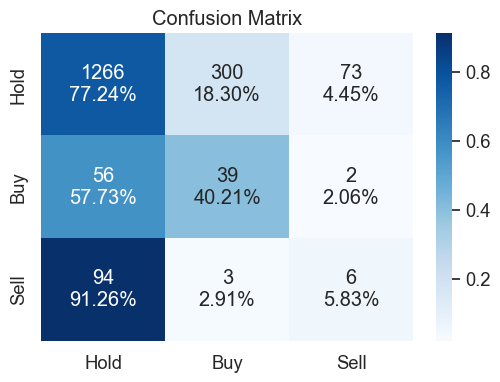

In [176]:
import utils
model_name = "CNN_MultiHead"    
for model_name in list_of_models:
    model_name = model_name._name
    print('Model name:',model_name)

    x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)

    label_pred = trained_best_models[model_name].predict(x_data)
    print(model_name,' classification Accuracy',
                    utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                    np.argmax(label_pred,axis=1),average="micro"))

    cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
    
    try:
        utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
    except:
        print(cf_matrix)

Model name: CNN_MultiHead
58/58 [==============================] - 0s 8ms/step
CNN_MultiHead  classification Accuracy 0.6751904243743199


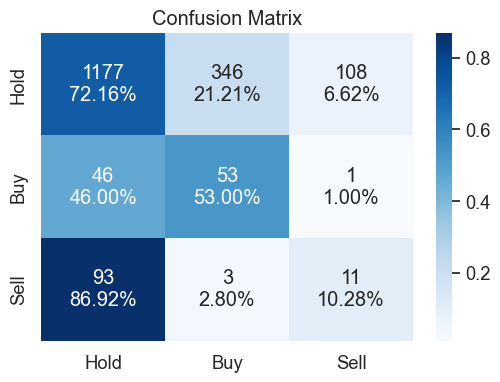

In [177]:
model_name = "CNN_MultiHead"  
print('Model name:',model_name)

x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

In [178]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []

    def execute_trade(self, signal, price):
        if signal == 'Buy' and self.balance > 0:
            self.position = self.balance / price
            self.balance = 0
        elif signal == 'Sell' and self.position > 0:
            self.balance = self.position * price
            self.position = 0

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]

            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.data.index, self.portfolio_value, label='Portfolio Value')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.title('Portfolio Performance')
        plt.legend()
        plt.show()

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')

        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

self.pred_days 12
input data shape (11984, 16, 24)
output data shape (11984, 3)
375/375 [==============================] - 2s 5ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([2394, 8928,  662], dtype=int64))


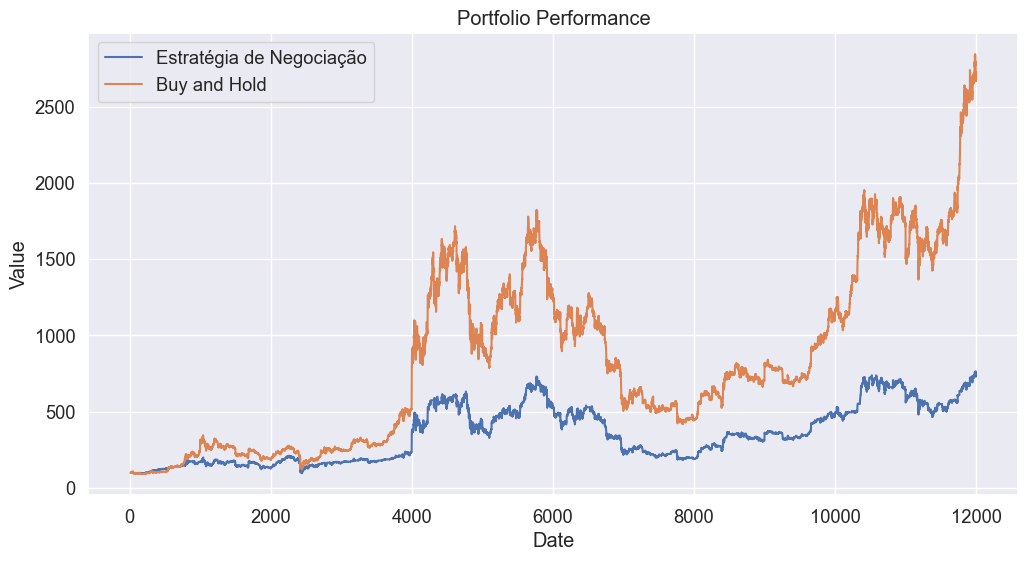

Retorno da Estratégia de Negociação: 633.19%
Retorno da Estratégia de Buy and Hold: 2580.51%


In [179]:
# Parâmetros iniciais
symbol=['BTC']
interval = '4h'
start_time = '2019-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    #list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals, return_counts=True))
    trade_signals=generate_signals(signals)
    
    trade_signals=signals
    data=data.iloc[-len(signals):,:]


    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    #backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals = ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")